<a href="https://colab.research.google.com/github/Rick2898/Series_tiempo_prom_movil-/blob/main/ACTIVIDAD_1/Entrega.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" 
    alt="Open In Colab"/>
</a>

# PRONOSTICO SERIES DE TIEMPO
### Carlos Preciado
### Jefferson Martinez
### Ricardo Vargas

En el siguiente notebook se encontrara el pronostico de series de tiempo con ayuda del promedio movil, esto se hara con una data de empleo de las 13 principales ciudades de colombia en miles de personas

## Carga de librerias


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.ticker import PercentFormatter
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Carga datos

In [69]:
df_empleos= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleos.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


In [70]:
print(df_empleos.shape)

(222, 4)


## Exploracion inicial

In [71]:
df_empleos.info(show_counts=True)

<class 'pandas.DataFrame'>
DatetimeIndex: 222 entries, 2001-01-01 to 2019-06-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TD_13ciudades  222 non-null    float64
 1   Ocupados       222 non-null    float64
 2   Desocupados    222 non-null    float64
 3   Inactivos      222 non-null    float64
dtypes: float64(4)
memory usage: 8.7 KB


In [72]:
print(df_empleos.index.freq)

None


### Validación de datos (frecuencia de tiempo)

In [73]:
pd.infer_freq(df_empleos.index)

'MS'

el Resultado es "MS" tiene una frecuencuencia perfecta son mensuales e inician el primer día del mes

In [74]:
# indenticación de los años únicos en el índice de tiempo
df_empleos.index.year.unique()

Index([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019],
      dtype='int32', name='mes')

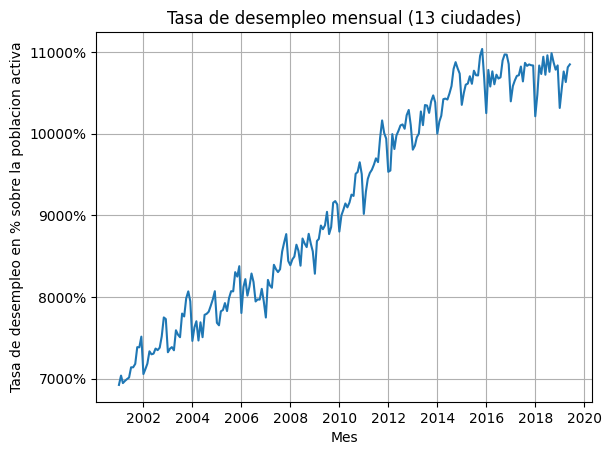

In [75]:
# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo en % sobre la poblacion activa")
plt.plot(df_empleos[["Ocupados"]], label="Ocupados")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100,decimals=0))
plt.grid()
plt.show()

## Componentes de la serie de tiempo, exploracion aditiva vs multiplicativa

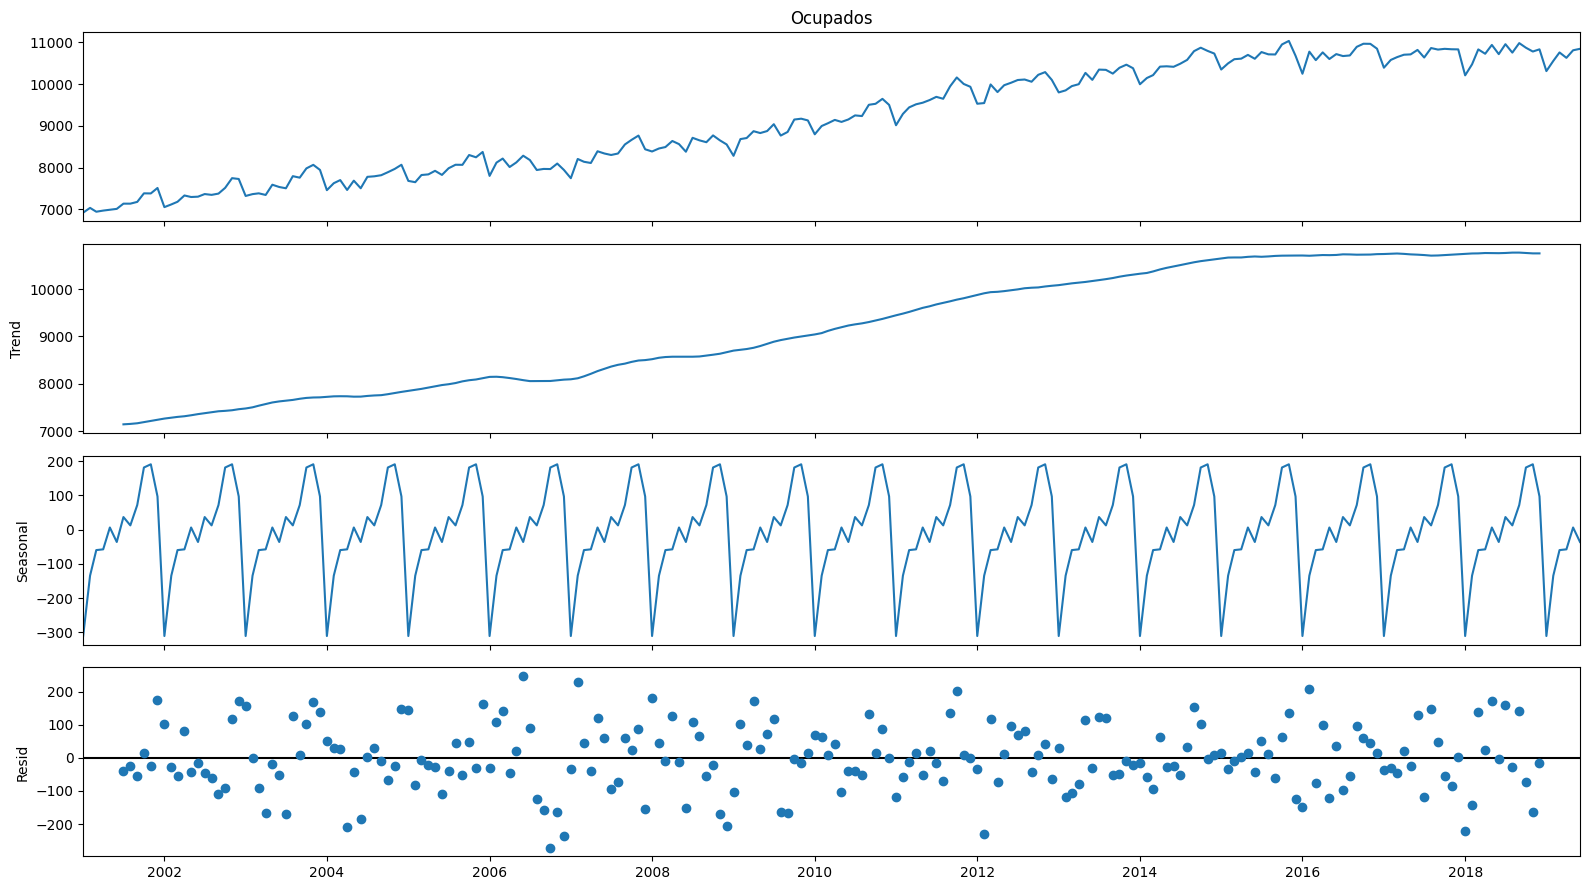

In [76]:
td_componentes_aditiva = seasonal_decompose(
    df_empleos["Ocupados"],
    model="additive",
    period=12
)
fig = td_componentes_aditiva.plot()
fig.set_size_inches((16,9))
fig.tight_layout()
plt.show()

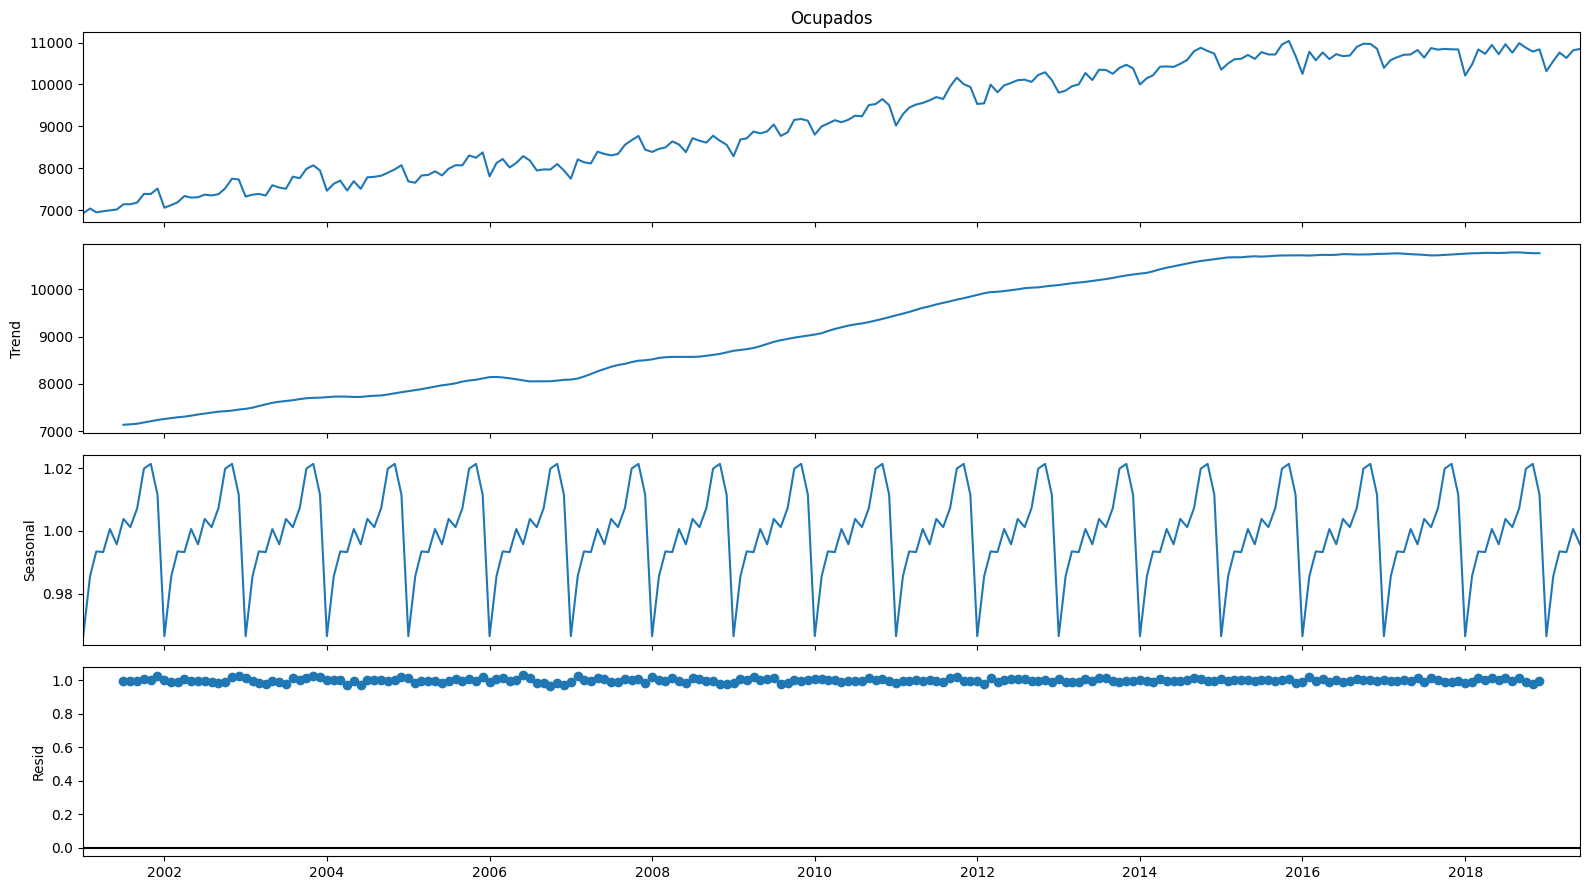

In [77]:
td_componentes_multiplicativa= seasonal_decompose(
    df_empleos["Ocupados"],
    model="multiplicative",
    period=12
)
fig = td_componentes_multiplicativa.plot()
fig.set_size_inches((16,9))
fig.tight_layout()
plt.show()

Se selecciona una descomposición aditiva debido a que la amplitud de las fluctuaciones estacionales permanece relativamente constante a lo largo del tiempo y no aumenta proporcionalmente con el nivel de la serie

## Evaluacion

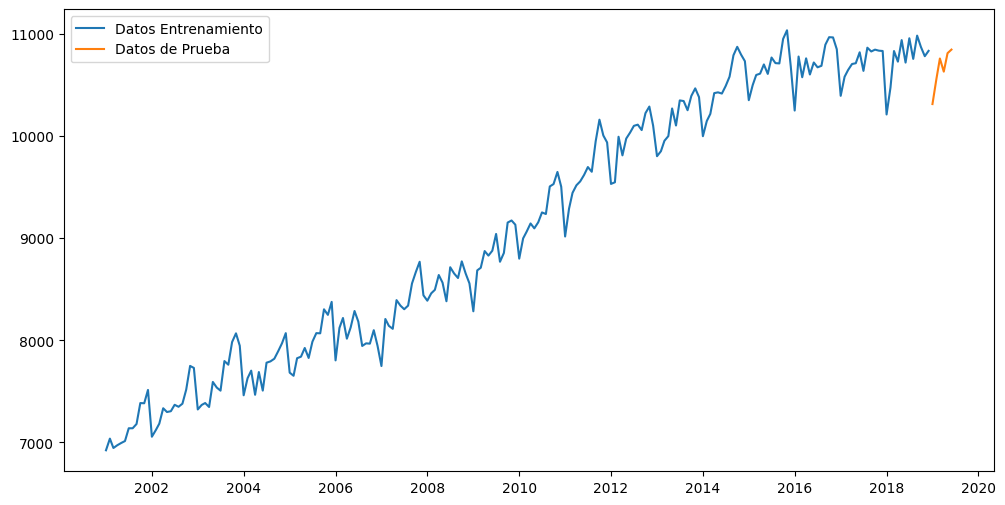

In [78]:
train_len = 216
train_td = df_empleos[["Ocupados"]][:train_len]
test_td = df_empleos[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [79]:
train_td

,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338


In [80]:
test_td 

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


## Promedios moviles

In [81]:
ma_2 = train_td.rolling(2, min_periods=2).mean()
ma_3 = train_td.rolling(3, min_periods=2).mean()
ma_4 = train_td.rolling(4, min_periods=2).mean()
ma_5 = train_td.rolling(5, min_periods=2).mean()
ma_6 = train_td.rolling(6, min_periods=2).mean()

In [82]:

def fore_ma(df_empleos,w,h):
  data=df_empleos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

## Elección de la ventana de promedio movil


In [88]:
ma_2_f= fore_ma(train_td,2,6)
ma_3_f= fore_ma(train_td,3,6)
ma_4_f= fore_ma(train_td,4,6)
ma_5_f= fore_ma(train_td,5,6)
ma_6_f= fore_ma(train_td,6,6)
ma_7_f= fore_ma(train_td,7,6)
ma_8_f= fore_ma(train_td,8,6)
ma_9_f= fore_ma(train_td,9,6)
ma_10_f= fore_ma(train_td,10,6)

In [89]:
test_td

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


In [90]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_td,ma_2_f ))
rmse_ma_3 = np.sqrt(mean_squared_error(test_td,ma_3_f ))
rmse_ma_4 = np.sqrt(mean_squared_error(test_td,ma_4_f ))
rmse_ma_5 = np.sqrt(mean_squared_error(test_td,ma_5_f ))
rmse_ma_6 = np.sqrt(mean_squared_error(test_td,ma_6_f ))
rmse_ma_7 = np.sqrt(mean_squared_error(test_td,ma_7_f ))
rmse_ma_8 = np.sqrt(mean_squared_error(test_td,ma_8_f ))
rmse_ma_9 = np.sqrt(mean_squared_error(test_td,ma_9_f ))
rmse_ma_10 = np.sqrt(mean_squared_error(test_td,ma_10_f ))

## Selección del mejor RMSE

In [92]:
print( f"""últimos 2 valores: {rmse_ma_2}, últimos 3 valores: {rmse_ma_3}, 
      últimos 4 valores: {rmse_ma_4}, últimos 5 valores: {rmse_ma_5},
        últimos 6 valores: {rmse_ma_6}, últimos 7 valores: {rmse_ma_7},
          últimos 8 valores: {rmse_ma_8}, últimos 9 valores: {rmse_ma_9},
          últimos 10 valores: {rmse_ma_10}""")

últimos 2 valores: 242.8347290019203, últimos 3 valores: 250.36984465630144, 
      últimos 4 valores: 270.6203851653251, últimos 5 valores: 266.5247179311155,
        últimos 6 valores: 272.83744069293607, últimos 7 valores: 269.605171526337,
          últimos 8 valores: 270.14397611273165, últimos 9 valores: 267.1880092607336,
          últimos 10 valores: 263.23104811759316


el mejor rmse de los Ocupados es con los últimos 2 valores

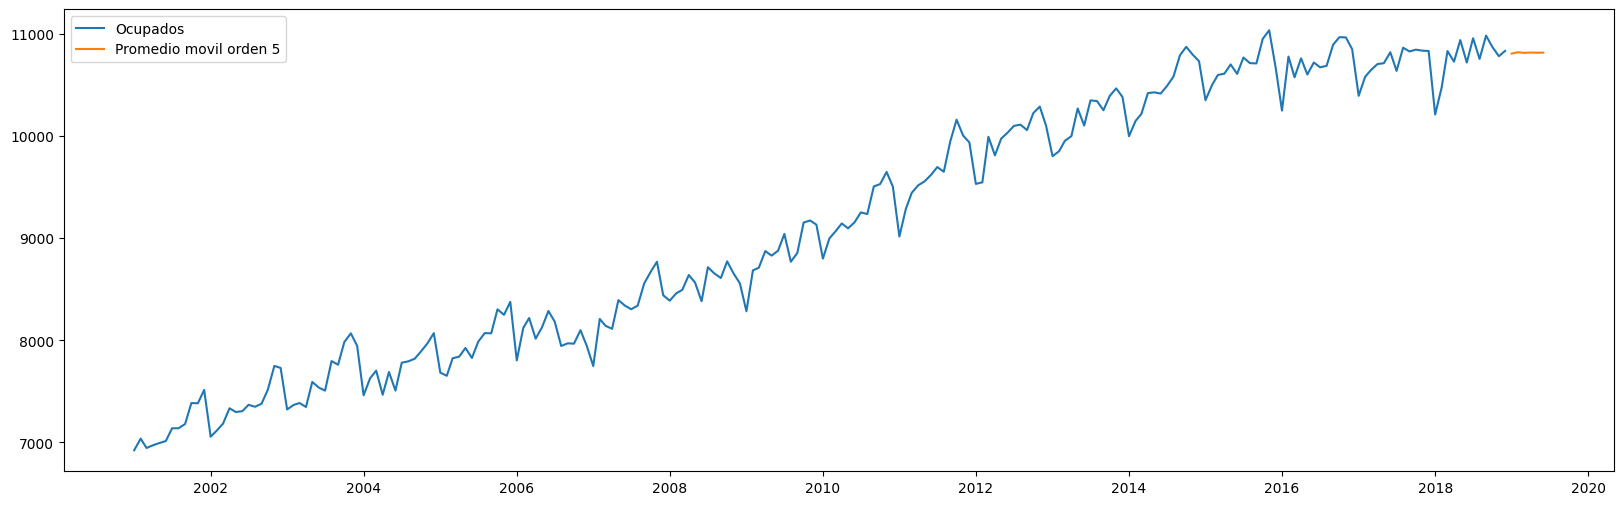

In [ ]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_td,label="Ocupados")
plt.plot(ma_2_f,label="Promedio movil orden 2")
plt.legend()
plt.show()

ahora tenemos que ahcerlo con todos los datos que hay y proyectar a 6 meses con el orden de 6 que usa 200 datos